# 06 — XNAV Demo

This notebook demonstrates the basic idea of X-ray pulsar navigation using timing and phase shifts.

## Objectives

- use the folded pulse profile concept;
- simulate or inspect pulse phase shifts;
- connect phase shifts with timing errors;
- explain how timing differences can be used in navigation-related calculations.

Filtered events: 540091


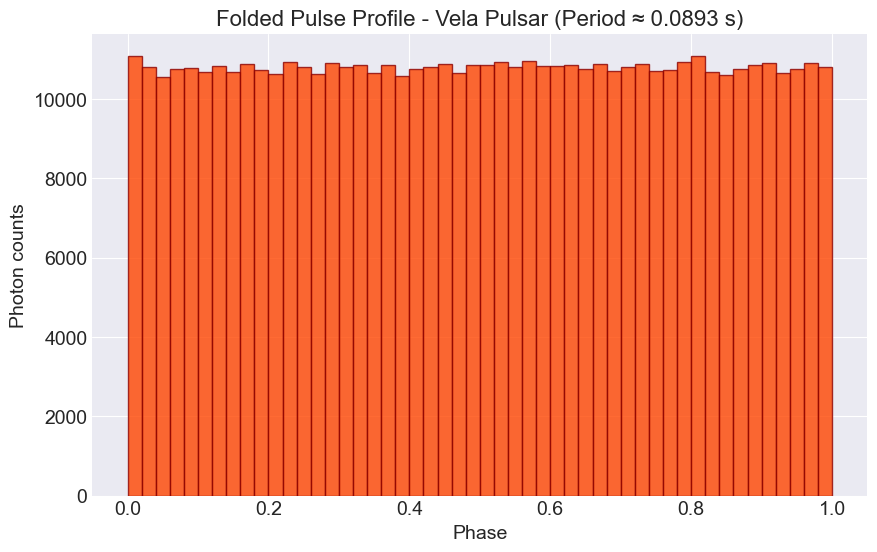

Phase shift: 0.020 → Time delay: 1.786 ms


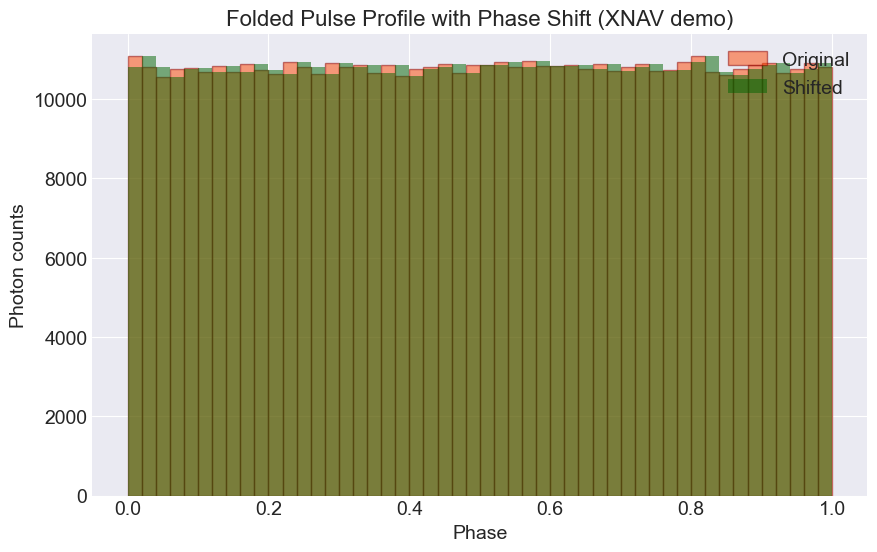

Period error δP=0.0001s over 1000s → Phase error=1.1200, Time error=100.00 ms


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'figure.figsize': (10,6),
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'lines.linewidth': 2,
    'lines.color': 'orangered',
})

hdul = fits.open('../data/raw/vela_photons.fits')
events = hdul[1].data

df = pd.DataFrame({
    "time": events["TIME"].astype('float64'),
    "energy": events["ENERGY"].astype('float64')
})

df_filtered = df[df["energy"] > 100]
print(f"Filtered events: {len(df_filtered)}")


dominant_freq = 11.2  
dominant_period = 1 / dominant_freq

time = df_filtered['time'].values
phase = (time % dominant_period) / dominant_period

n_bins = 50
counts, bin_edges = np.histogram(phase, bins=n_bins)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.figure()
plt.bar(bin_centers, counts, width=1/n_bins, color='orangered', edgecolor='darkred', alpha=0.8)
plt.xlabel('Phase')
plt.ylabel('Photon counts')
plt.title(f'Folded Pulse Profile - Vela Pulsar (Period ≈ {dominant_period:.4f} s)')
plt.show()

phase_shift = 0.02  
time_delay = phase_shift * dominant_period
print(f"Phase shift: {phase_shift:.3f} → Time delay: {time_delay*1000:.3f} ms")

plt.figure()
plt.bar(bin_centers, counts, width=1/n_bins, color='orangered', edgecolor='darkred', alpha=0.5, label='Original')
plt.bar((bin_centers + phase_shift) % 1, counts, width=1/n_bins, color='darkgreen', alpha=0.5, label='Shifted')
plt.xlabel('Phase')
plt.ylabel('Photon counts')
plt.title('Folded Pulse Profile with Phase Shift (XNAV demo)')
plt.legend()
plt.show()

delta_P = 1e-4
observation_time = 1000  

phase_error = (delta_P / dominant_period) * observation_time
time_error = phase_error * dominant_period
print(f"Period error δP={delta_P}s over {observation_time}s → Phase error={phase_error:.4f}, Time error={time_error*1000:.2f} ms")


In [2]:
import os
import matplotlib.pyplot as plt

images_dir = 'images'
os.makedirs(images_dir, exist_ok=True)

figures = [plt.figure(n) for n in plt.get_fignums()]

notebook_name = '05_xnav_demo'

for i, fig in enumerate(figures, start=1):
    filename = f"{notebook_name}_fig{i}.png"
    filepath = os.path.join(images_dir, filename)
    fig.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"Saved: {filepath}")

plt.close('all')


## Conclusion

This notebook demonstrates how pulsar phase shifts can be interpreted as timing differences.  
The example connects pulsar timing analysis with the basic idea behind X-ray pulsar navigation.